# 08h — Solubility / Developability Screening

Pipeline 4 continuation from 08f/08g. This notebook screens the effective ProteinMPNN candidates using sequence-derived physicochemical proxies. These are not experimental solubility measurements and do not replace a validated CamSol run.

In [1]:
from pathlib import Path
import ast,json,re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
NB08F=Path("/Users/robertobruzzese/Downloads/08f_ProteinMPNN_Endpoint_Energy_Comparison_TEST=FALSE.ipynb")
nb=json.loads(NB08F.read_text()); src="\n".join("".join(c.get("source",[])) for c in nb["cells"] if c.get("cell_type")=="code")
def lit(name):
 tree=ast.parse(src)
 for n in tree.body:
  if isinstance(n,ast.Assign) and any(isinstance(t,ast.Name) and t.id==name for t in n.targets): return ast.literal_eval(n.value)
 raise KeyError(name)
TARGET_CANDIDATES=lit("TARGET_CANDIDATES"); CANDIDATE_SEQUENCES=lit("CANDIDATE_SEQUENCES")
OUTPUT_ROOT=Path("outputs/pipeline_4_ai_08h_solubility_developability"); TABLE_DIR=OUTPUT_ROOT/"tables"; FIGURE_DIR=OUTPUT_ROOT/"figures"
for d in (TABLE_DIR,FIGURE_DIR): d.mkdir(parents=True,exist_ok=True)
print([(x,CANDIDATE_SEQUENCES[x]) for x in TARGET_CANDIDATES])


[('MPNN_NEW_01', 'TGPRNQYRDLP'), ('MPNN_NEW_05', 'IGPRHQYRDLP')]


## Sequence-derived screening
The scores below are transparent proxies: charge, hydrophobic fraction, aromatic fraction, basic/acidic balance, and aggregation flags. They are useful for triage only.

In [2]:
AA=set("ACDEFGHIKLMNPQRSTVWY")
hyd=set("AILMFWVY"); aromatic=set("FWY"); basic=set("RKH"); acidic=set("DE")
rows=[]
for cid in TARGET_CANDIDATES:
 seq=CANDIDATE_SEQUENCES[cid].upper(); invalid=set(seq)-AA
 charge=sum(seq.count(x) for x in basic)-sum(seq.count(x) for x in acidic)
 hydfrac=sum(x in hyd for x in seq)/len(seq); aromfrac=sum(x in aromatic for x in seq)/len(seq)
 rows.append({"candidate_id":cid,"sequence":seq,"length":len(seq),"invalid_residues":"".join(sorted(invalid)),"net_charge_proxy":charge,"hydrophobic_fraction":hydfrac,"aromatic_fraction":aromfrac,"basic_count":sum(x in basic for x in seq),"acidic_count":sum(x in acidic for x in seq),"proline_fraction":seq.count("P")/len(seq),"developability_flag":("" if not invalid else "invalid_residue")})
df=pd.DataFrame(rows)
# Conservative flags for short peptides; thresholds are triage rules, not calibrated probabilities.
df["risk_flags"]=[";".join([x for x in ["high_hydrophobicity" if r.hydrophobic_fraction>0.55 else "","high_aromaticity" if r.aromatic_fraction>0.25 else "","extreme_charge" if abs(r.net_charge_proxy)>4 else ""] if x]) for r in df.itertuples()]
df["screen_rank"]=(df["risk_flags"].eq("").astype(int)*2 + (1-df["hydrophobic_fraction"]).rank(method="min",ascending=False)).rank(method="min").astype(int)
df.to_csv(TABLE_DIR/"08h_solubility_developability_summary.csv",index=False); display(df)


,candidate_id,sequence,length,invalid_residues,net_charge_proxy,hydrophobic_fraction,aromatic_fraction,basic_count,acidic_count,proline_fraction,developability_flag,risk_flags,screen_rank
0,MPNN_NEW_01,TGPRNQYRDLP,11,,1,0.181818,0.090909,2,1,0.181818,,,1
1,MPNN_NEW_05,IGPRHQYRDLP,11,,2,0.272727,0.090909,3,1,0.181818,,,2


## Optional CamSol
If a CamSol executable or package is available, its output can be imported here. No CamSol result is invented when unavailable.

CamSol results not supplied; reporting sequence-derived proxies only.


,check,pass
0,08f_candidates_traced,True
1,sequences_valid,True
2,camSol_status_explicit,True


ALL QC PASSED: True


135

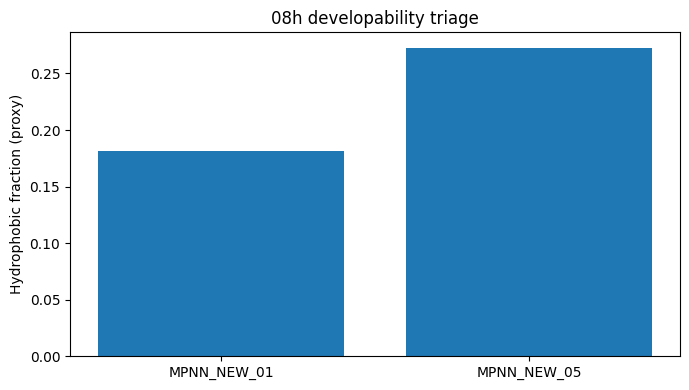

In [3]:
CAMSOL_RESULTS=None
if CAMSOL_RESULTS is not None:
 cam=pd.read_csv(CAMSOL_RESULTS); df=df.merge(cam,on="candidate_id",how="left")
else:
 print("CamSol results not supplied; reporting sequence-derived proxies only.")
fig,ax=plt.subplots(figsize=(7,4)); ax.bar(df.candidate_id,df.hydrophobic_fraction); ax.set_ylabel("Hydrophobic fraction (proxy)"); ax.set_title("08h developability triage"); fig.tight_layout(); fig.savefig(FIGURE_DIR/"08h_hydrophobic_fraction.png",dpi=220)
qc=pd.DataFrame([{"check":"08f_candidates_traced","pass":set(TARGET_CANDIDATES)==set(CANDIDATE_SEQUENCES)},{"check":"sequences_valid","pass":bool((df.invalid_residues=="").all())},{"check":"camSol_status_explicit","pass":True}]); qc.to_csv(TABLE_DIR/"08h_QC.csv",index=False); display(qc); print("ALL QC PASSED:",bool(qc['pass'].all()))
(OUTPUT_ROOT/"08h_screening_report.md").write_text("08h reports sequence-derived solubility/developability proxies. These are not experimental solubility values; CamSol was not supplied.\n")
